# Decision Tree Regressor

#### Pedro Mauri Mtz - A01029143

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree

### Data science

In [3]:
df = pd.read_csv(os.path.join(ROOT, "Datasets", "laptop.csv"))
df_copy = df.copy()
df.head()

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,CpuCompany,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,GPU,Ppi,Price
0,Apple,Ultrabook,8,macOS,1.37,0,Intel,2.3,0.000,0.0,0.0,0.128,Intel,312.781955,71378.6832
1,Apple,Ultrabook,8,macOS,1.34,0,Intel,1.8,0.128,0.0,0.0,0.000,Intel,175.939850,47895.5232
2,HP,Notebook,8,No,1.86,0,Intel,2.5,0.000,0.0,0.0,0.256,Intel,192.307692,30636.0000
3,Apple,Ultrabook,16,macOS,1.83,0,Intel,2.7,0.000,0.0,0.0,0.512,AMD,303.896104,135195.3360
4,Apple,Ultrabook,8,macOS,1.37,0,Intel,3.1,0.000,0.0,0.0,0.256,Intel,312.781955,96095.8080


In [4]:
df.nunique()

Company           19
TypeName           6
Ram                9
OpSys              7
Weight           171
Touchscreen        2
CpuCompany         3
ClockSpeed        25
Flash Storage      7
HDD                6
Hybrid             3
SSD               13
GPU                4
Ppi               39
Price            791
dtype: int64

In [5]:
df.dtypes

Company              str
TypeName             str
Ram                int64
OpSys                str
Weight           float64
Touchscreen        int64
CpuCompany           str
ClockSpeed       float64
Flash Storage    float64
HDD              float64
Hybrid           float64
SSD              float64
GPU                  str
Ppi              float64
Price            float64
dtype: object

In [6]:
df.isna().sum()

Company          0
TypeName         0
Ram              0
OpSys            0
Weight           0
Touchscreen      0
CpuCompany       0
ClockSpeed       0
Flash Storage    0
HDD              0
Hybrid           0
SSD              0
GPU              0
Ppi              0
Price            0
dtype: int64

In [7]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [8]:
x = pd.get_dummies(x, drop_first = True)

In [9]:
x.head()

,Ram,Weight,Touchscreen,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,Ppi,Company_Apple,...,OpSys_Linux,OpSys_Mac,OpSys_No,OpSys_Windows,OpSys_macOS,CpuCompany_Intel,CpuCompany_Samsung,GPU_ARM,GPU_Intel,GPU_Nvidia
0,8,1.37,0,2.3,0.000,0.0,0.0,0.128,312.781955,True,...,False,False,False,False,True,True,False,False,True,False
1,8,1.34,0,1.8,0.128,0.0,0.0,0.000,175.939850,True,...,False,False,False,False,True,True,False,False,True,False
2,8,1.86,0,2.5,0.000,0.0,0.0,0.256,192.307692,False,...,False,False,True,False,False,True,False,False,True,False
3,16,1.83,0,2.7,0.000,0.0,0.0,0.512,303.896104,True,...,False,False,False,False,True,True,False,False,False,False
4,8,1.37,0,3.1,0.000,0.0,0.0,0.256,312.781955,True,...,False,False,False,False,True,True,False,False,True,False


In [10]:
y.head()

0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64

### Create datasets

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

### Arbol de Decisión de Regresión

In [12]:
# DTR_model = DecisionTreeRegressor(max_depth = 18, min_samples_leaf = 8, min_samples_split = 10, ccp_alpha = 0.1)
DTR_model = DecisionTreeRegressor()

### Training

In [13]:
# Train the model
DTR_model.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [14]:
y_pred_train_data = DTR_model.predict(x_train)
r2_train_data = r2_score(y_train, y_pred_train_data)
print(f"Model R2 Score on Training Data: {r2_train_data}")

Model R2 Score on Training Data: 0.995988469932421


### Testing

In [15]:
# Test the model
y_pred = DTR_model.predict(x_test)

In [16]:
r2 = r2_score(y_test, y_pred)
print(f"Model R2 Score on Test Data: {r2}")

Model R2 Score on Test Data: 0.7257850998456312


## Visualize the Tree

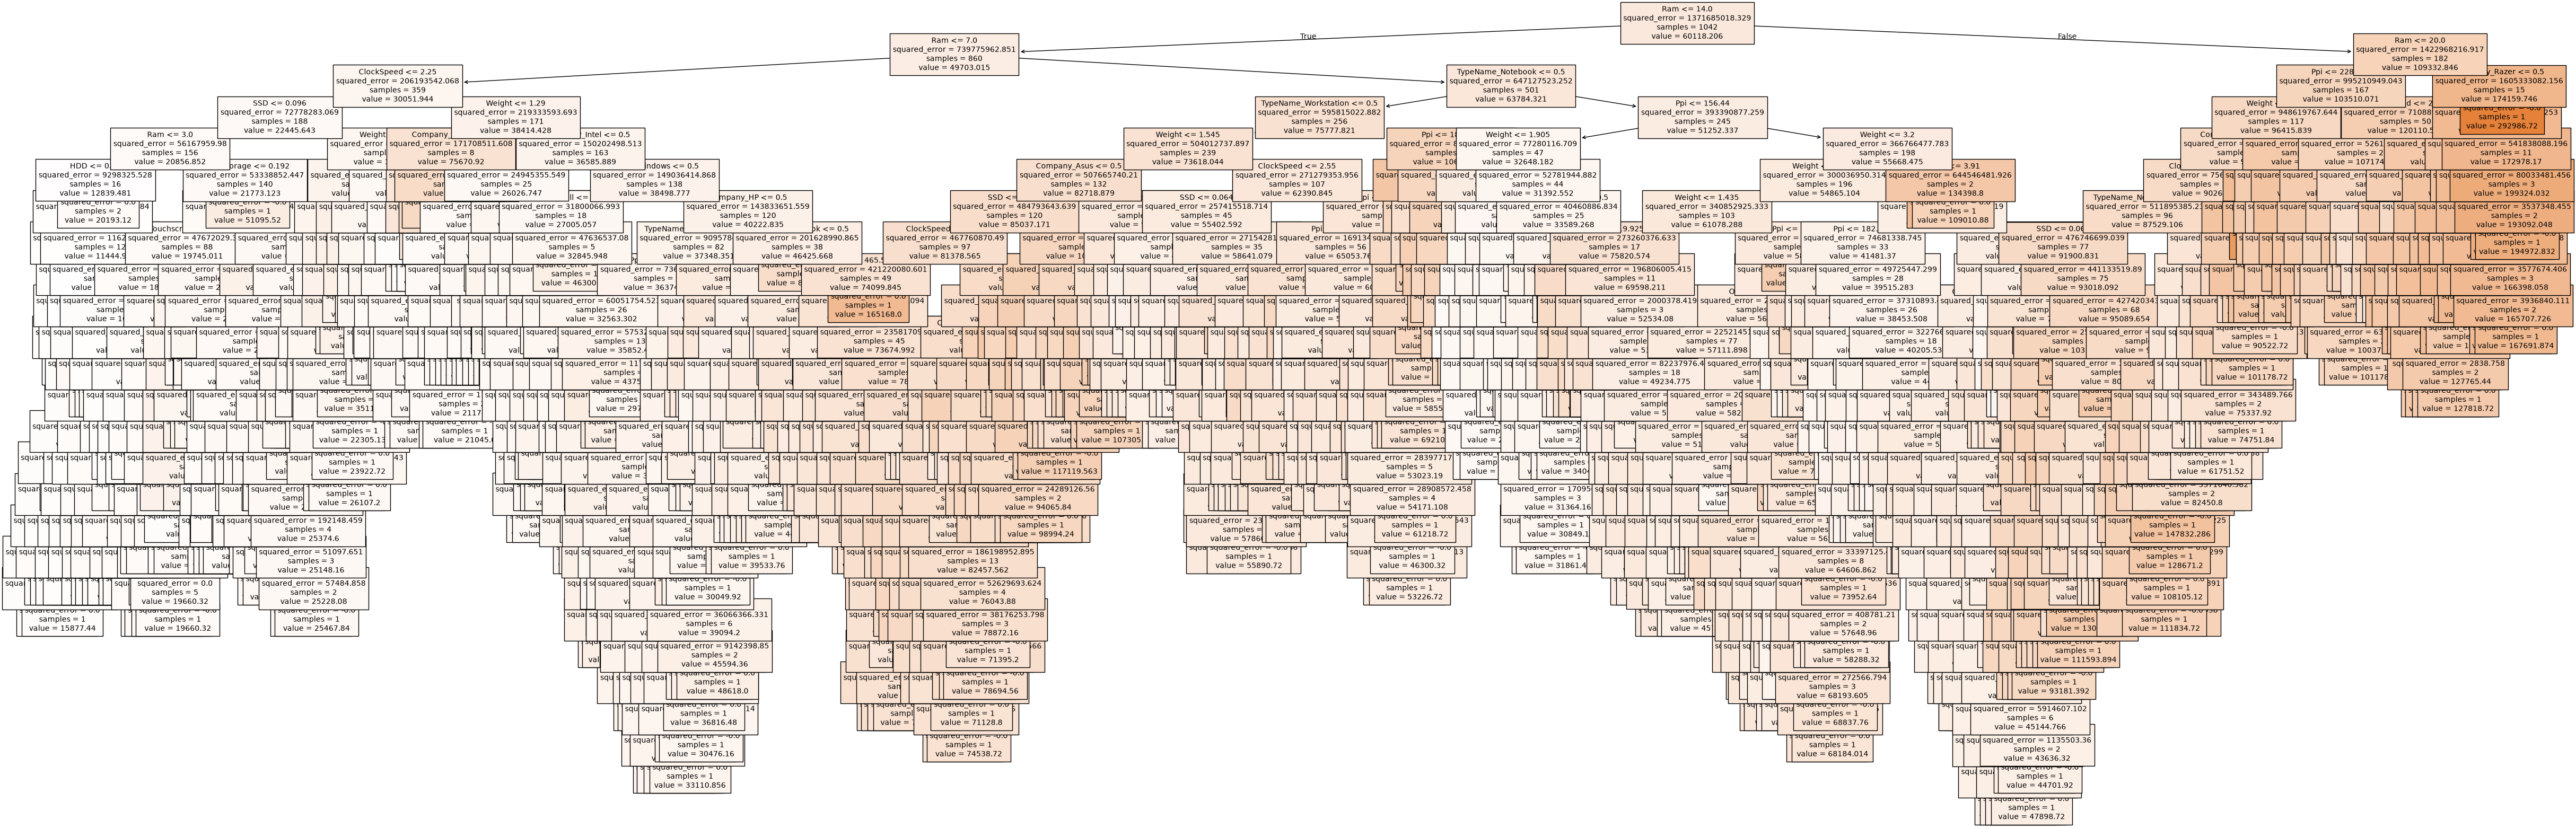

In [17]:
plt.figure(figsize = (60, 20))
plot_tree(DTR_model, filled = True, feature_names = x.columns, fontsize = 10)
plt.show()